# Liason des outils

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Recuperation des données et Importation des module

In [4]:
import missingno as msno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

recuper_prediction_csv = pd.read_csv("/content/drive/MyDrive/fisrt_projet/Dataset/rent_prediction.csv")
print(recuper_prediction_csv)

     IdentifiantMaison  Chambres Salon SalleDeBainInterieure Parking Meuble  \
0                    1       4.0   Oui                   Oui     NaN    Non   
1                    2       5.0   Oui                   Oui     Non    Oui   
2                    3       3.0   Oui                   Oui     Non    Non   
3                    4       5.0   Oui                   Oui     Oui    Oui   
4                    5       5.0   Oui                   Oui     Oui    NaN   
..                 ...       ...   ...                   ...     ...    ...   
505                506       5.0   Oui                   Oui     Oui    Oui   
506                507       5.0   Oui                   Oui     Non    Non   
507                508       4.0   Oui                   Oui     Oui    Non   
508                509       6.0   Oui                   Oui     Non    Non   
509                510       5.0   Oui                   Oui     Oui    Non   

    Jardin  Superficie_m2  DistanceRoute_m    Quart

#COMPREHENSION DU JEUX DE DONNEES

## Visualisation

In [5]:
# /////////les premier coup d'oeil////////

recuper_prediction_csv.head()
recuper_prediction_csv.describe()
recuper_prediction_csv.dtypes
recuper_prediction_csv.info()
value_nan = recuper_prediction_csv.isna().sum()
print (f"voici les valeur null :{value_nan}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IdentifiantMaison      510 non-null    int64  
 1   Chambres               485 non-null    float64
 2   Salon                  485 non-null    object 
 3   SalleDeBainInterieure  485 non-null    object 
 4   Parking                485 non-null    object 
 5   Meuble                 485 non-null    object 
 6   Jardin                 485 non-null    object 
 7   Superficie_m2          485 non-null    float64
 8   DistanceRoute_m        485 non-null    float64
 9   Quartier               485 non-null    object 
 10  AgeMaison              485 non-null    float64
 11  LoyerMensuel_BIF       510 non-null    int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 47.9+ KB
voici les valeur null :IdentifiantMaison         0
Chambres                 25
Salon                    

## Analyser le mécanisme des valeurs manquantes

In [6]:
# /////////je recupere toute les ligne qui contienne aumoin un nan//////////

ligne_nan = recuper_prediction_csv[recuper_prediction_csv.isna().any(axis = 1)]
print(f" voici le ligne des notre data qui contienne aumoin 1Nan  :{ligne_nan}")

#///////recuparation des valeur nul par colone////////
nan_col = recuper_prediction_csv.isna().mean() * 100
print(f" voici le valeur nul par colonne en porcentage :{nan_col}")



 voici le ligne des notre data qui contienne aumoin 1Nan  :     IdentifiantMaison  Chambres Salon SalleDeBainInterieure Parking Meuble  \
0                    1       4.0   Oui                   Oui     NaN    Non   
4                    5       5.0   Oui                   Oui     Oui    NaN   
5                    6       2.0   Non                   Oui     Oui    NaN   
7                    8       NaN   Oui                   Oui     Non    Non   
14                  15       2.0   NaN                   Non     Non    Non   
..                 ...       ...   ...                   ...     ...    ...   
501                502       3.0   Oui                   Non     Non    Non   
503                504       5.0   NaN                   Oui     Oui    Non   
505                506       5.0   Oui                   Oui     Oui    Oui   
508                509       6.0   Oui                   Oui     Non    Non   
509                510       5.0   Oui                   Oui     Oui    

## Statistique descriptive

In [7]:
# //////Statistiques des variables numériques//////
print("Variables Numériques")
display(recuper_prediction_csv.describe().T[['mean', 'std', 'min', '50%', 'max']])

# //////// Statistiques des variables catégorielles//////
print("Variables Catégorielles ")
display(recuper_prediction_csv.describe(include=['object', 'category']).T)

Variables Numériques


,mean,std,min,50%,max
IdentifiantMaison,2.555000e+02,147.368586,1.0,255.5,510.0
Chambres,3.521649e+00,1.707436,1.0,4.0,6.0
Superficie_m2,1.685876e+02,79.464914,30.0,171.0,320.0
DistanceRoute_m,1.546371e+02,85.262406,6.0,154.0,300.0
AgeMaison,1.993402e+01,11.544729,0.0,20.0,40.0
LoyerMensuel_BIF,1.244608e+06,700433.136451,136149.0,1082640.0,2600000.0


Variables Catégorielles 


,count,unique,top,freq
Salon,485,2,Oui,450
SalleDeBainInterieure,485,2,Oui,394
Parking,485,2,Oui,282
Meuble,485,2,Non,392
Jardin,485,2,Non,305
Quartier,485,14,Nyakabiga,49


## Analyser de la distribution de LoyerMensuel_BIF

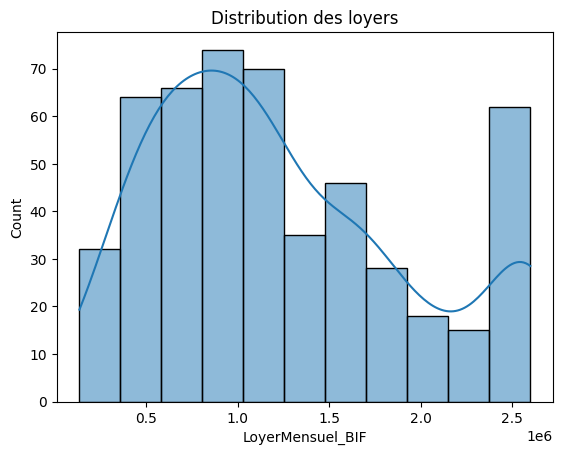

In [8]:
sns.histplot(recuper_prediction_csv['LoyerMensuel_BIF'], kde=True)
plt.title("Distribution des loyers")
plt.show()

## Valeurs aberrantes

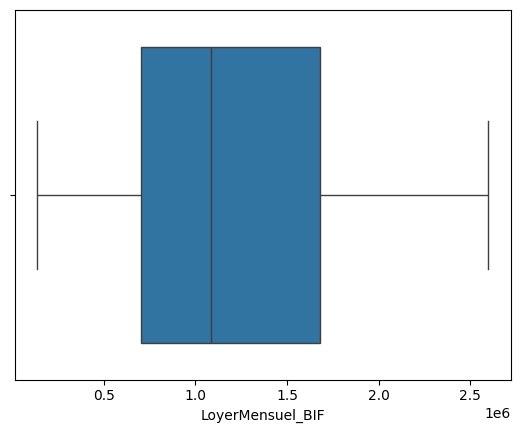

In [9]:
sns.boxplot(x=recuper_prediction_csv['LoyerMensuel_BIF'])
plt.show()

## Transformation Log éventuelle

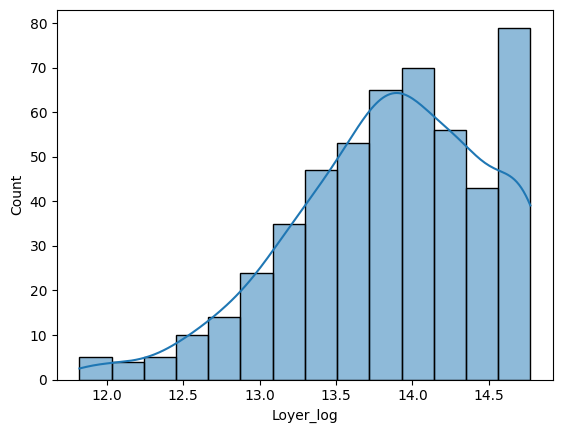

In [10]:
# On crée une nouvelle variable avec le log du loyer
recuper_prediction_csv['Loyer_log'] = np.log1p(recuper_prediction_csv['LoyerMensuel_BIF'])

# Visualiser la nouvelle distribution
sns.histplot(recuper_prediction_csv['Loyer_log'], kde=True)
plt.show()

 ## Analyser des feature numérique

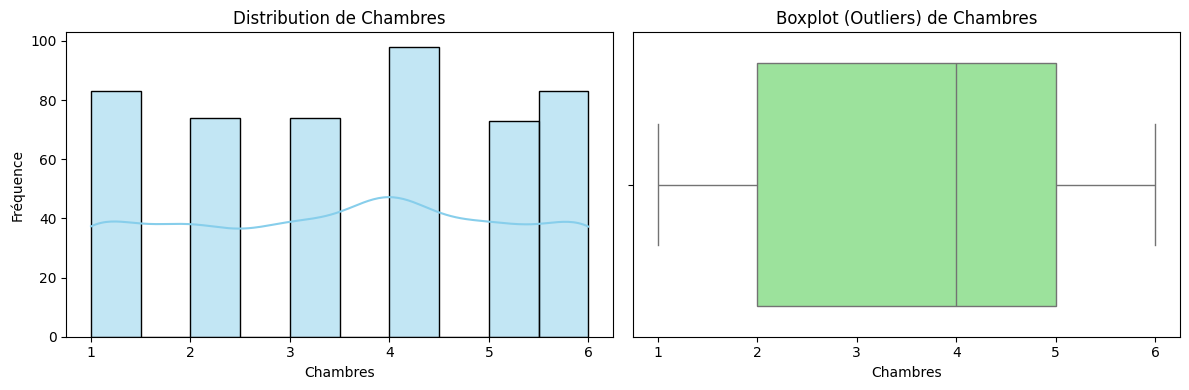

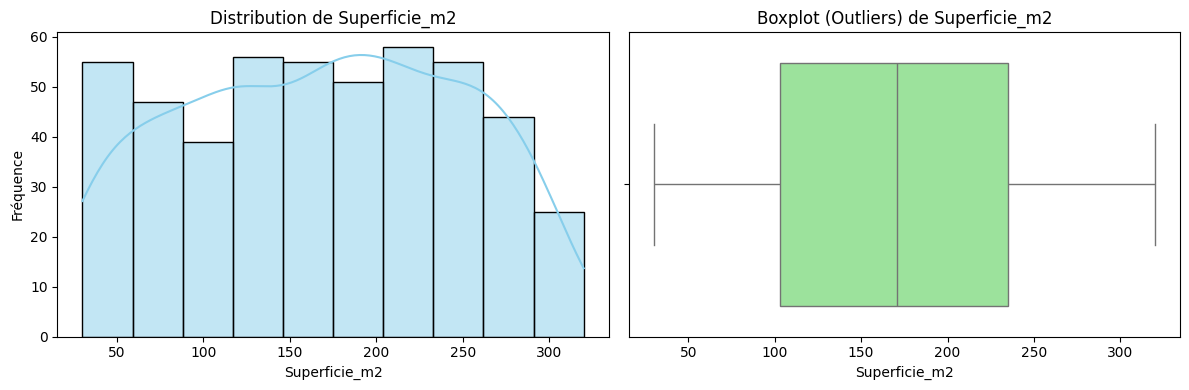

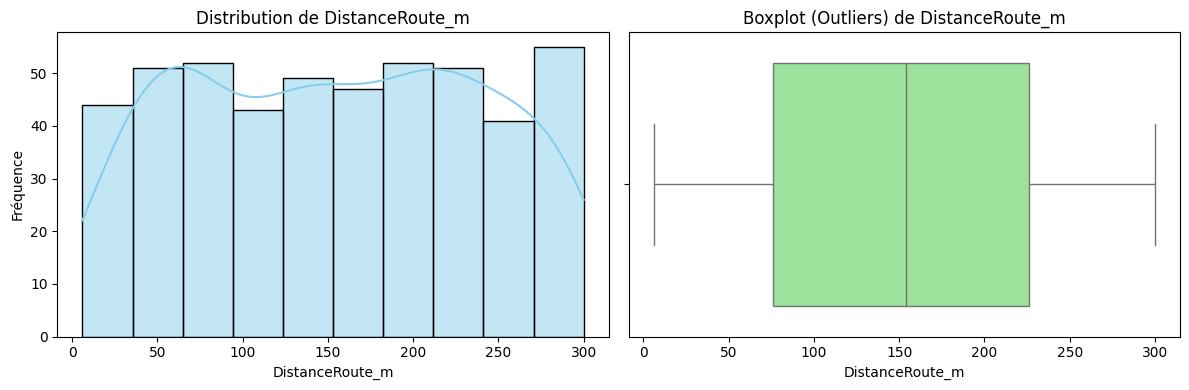

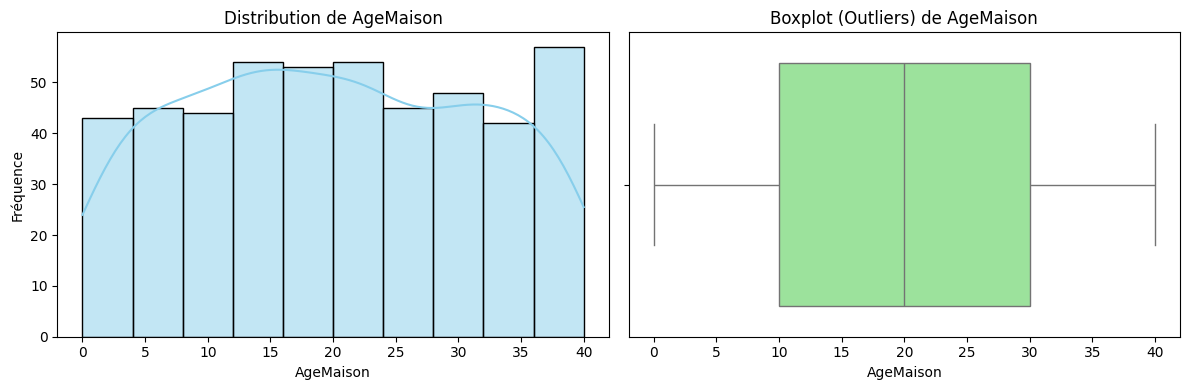

In [11]:

# Liste des features numériques à analyser
num_features = ['Chambres', 'Superficie_m2', 'DistanceRoute_m', 'AgeMaison']

# Tracé des distributions et boxplots
for col in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogramme avec courbe de densité (KDE)
    sns.histplot(recuper_prediction_csv[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Fréquence')

    # 2. Boxplot (Détection des Outliers)
    sns.boxplot(x=recuper_prediction_csv[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot (Outliers) de {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## Analyser des features catégorielles

In [12]:
# Liste des variables catégorielles à analyser
cat_features = ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin', 'Quartier']

for feature in cat_features:
    print(f"=== Analyse de : {feature} ===")

    # 1. Cardinalité (nombre de catégories uniques)
    cardinality = recuper_prediction_csv[feature].nunique(dropna=False)
    print(f"Cardinalité : {cardinality}")

    # 2. Distribution des fréquences (en effectif et en %)
    counts = recuper_prediction_csv[feature].value_counts(dropna=False)
    percentages = recuper_prediction_csv[feature].value_counts(normalize=True, dropna=False) * 100

    distribution = pd.DataFrame({'Effectif': counts, 'Pourcentage (%)': percentages})
    print(distribution)
    print("-" * 50)


=== Analyse de : Salon ===
Cardinalité : 3
       Effectif  Pourcentage (%)
Salon                           
Oui         450        88.235294
Non          35         6.862745
NaN          25         4.901961
--------------------------------------------------
=== Analyse de : SalleDeBainInterieure ===
Cardinalité : 3
                       Effectif  Pourcentage (%)
SalleDeBainInterieure                           
Oui                         394        77.254902
Non                          91        17.843137
NaN                          25         4.901961
--------------------------------------------------
=== Analyse de : Parking ===
Cardinalité : 3
         Effectif  Pourcentage (%)
Parking                           
Oui           282        55.294118
Non           203        39.803922
NaN            25         4.901961
--------------------------------------------------
=== Analyse de : Meuble ===
Cardinalité : 3
        Effectif  Pourcentage (%)
Meuble                           
Non

### Visualisation de la distribution des catégories

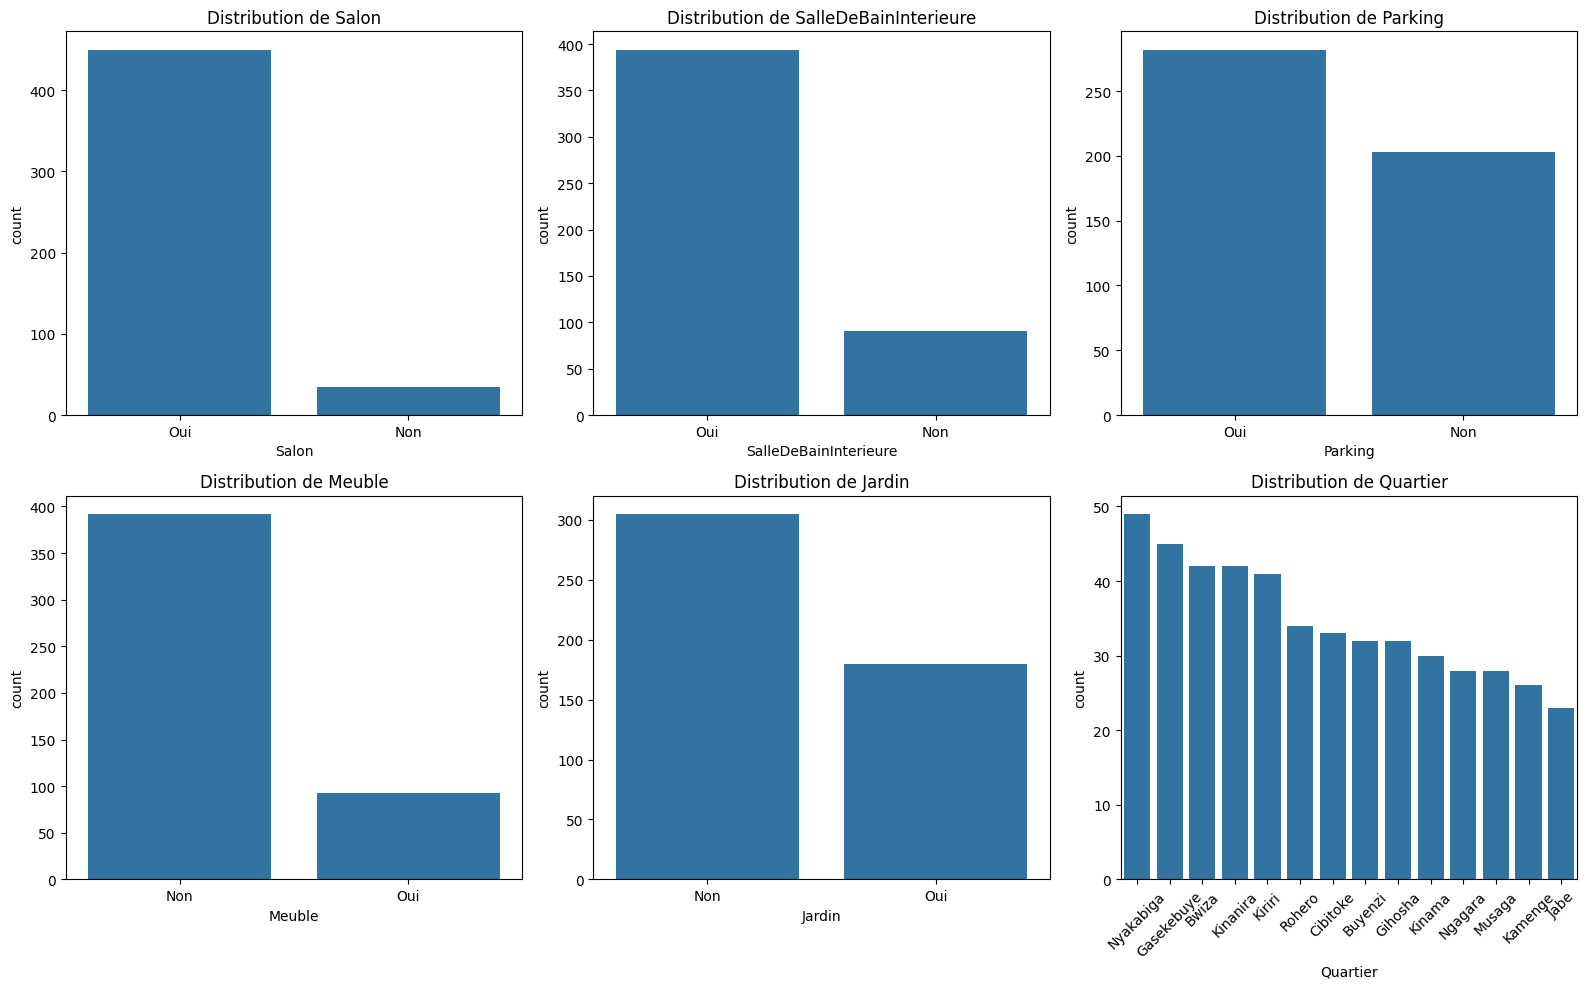

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    sns.countplot(data=recuper_prediction_csv, x=feature, ax=axes[i], order=recuper_prediction_csv[feature].value_counts().index)
    axes[i].set_title(f"Distribution de {feature}")
    axes[i].tick_params(axis='x', rotation=45 if feature == 'Quartier' else 0)

plt.tight_layout()
plt.show()

##  Étude du taux et de pattern des valeurs manquantes

In [14]:
# 1. Calcul du taux de valeurs manquantes par colonne
missing_summary = pd.DataFrame({
    'Total_Manquants': recuper_prediction_csv.isnull().sum(),
    'Pourcentage (%)': (recuper_prediction_csv.isnull().sum() / len(recuper_prediction_csv)) * 100
}).sort_values(by='Pourcentage (%)', ascending=False)

print("=== Taux de Valeurs Manquantes ===")
print(missing_summary[missing_summary['Total_Manquants'] > 0])


# /////////////////////////////////


=== Taux de Valeurs Manquantes ===
                       Total_Manquants  Pourcentage (%)
Chambres                            25         4.901961
SalleDeBainInterieure               25         4.901961
Salon                               25         4.901961
Parking                             25         4.901961
Meuble                              25         4.901961
Quartier                            25         4.901961
Jardin                              25         4.901961
Superficie_m2                       25         4.901961
DistanceRoute_m                     25         4.901961
AgeMaison                           25         4.901961


In [15]:
feature_with_na = 'Superficie_m2'

if recuper_prediction_csv[feature_with_na].isnull().sum() > 0:
    recuper_prediction_csv['is_missing'] = recuper_prediction_csv[feature_with_na].isnull()

    # Distribution des manquants par Quartier
    ct = pd.crosstab(recuper_prediction_csv['Quartier'], recuper_prediction_csv['is_missing'], normalize='index') * 100
    print(f"=== % de données manquantes sur {feature_with_na} par Quartier ===")
    print(ct)


=== % de données manquantes sur Superficie_m2 par Quartier ===
is_missing       False      True 
Quartier                         
Buyenzi     100.000000   0.000000
Bwiza        92.857143   7.142857
Cibitoke     96.969697   3.030303
Gasekebuye   93.333333   6.666667
Gihosha      96.875000   3.125000
Jabe         95.652174   4.347826
Kamenge      92.307692   7.692308
Kinama       96.666667   3.333333
Kinanira     95.238095   4.761905
Kiriri       97.560976   2.439024
Musaga       96.428571   3.571429
Ngagara     100.000000   0.000000
Nyakabiga    93.877551   6.122449
Rohero       88.235294  11.764706


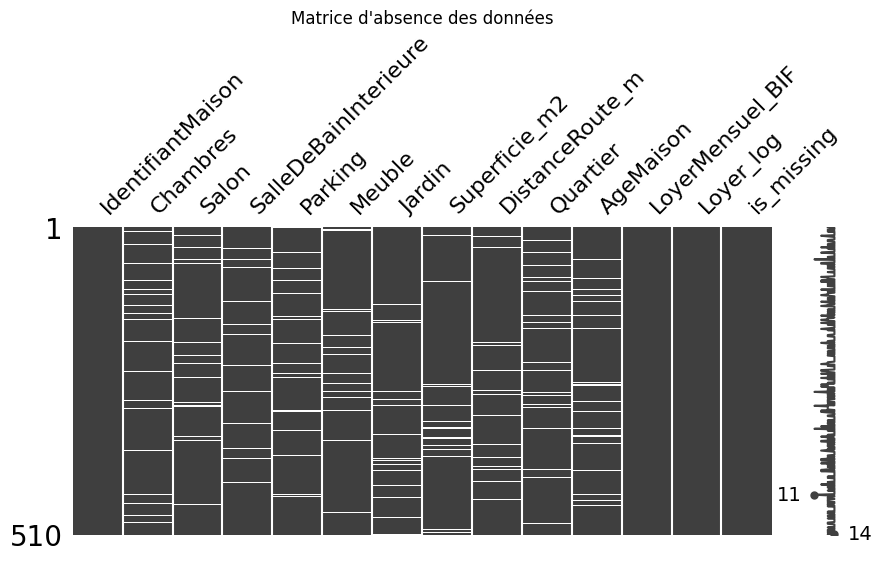

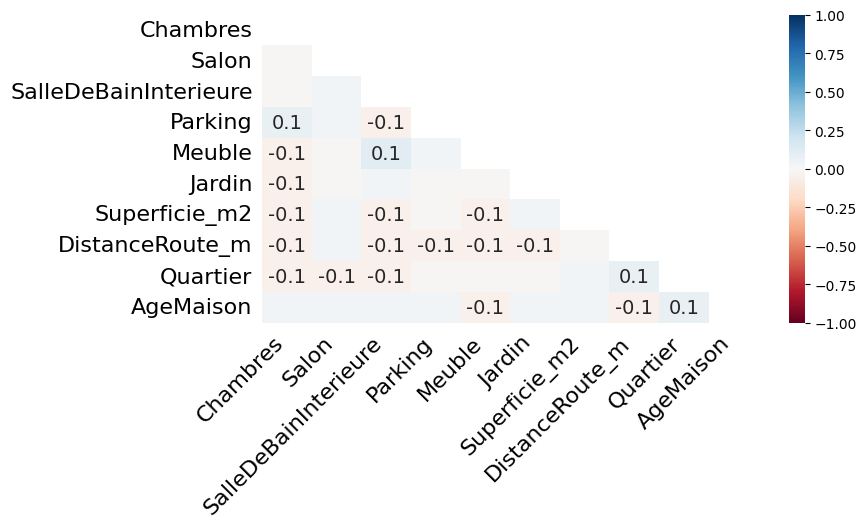

In [16]:
# Matrice de présence / absence
msno.matrix(recuper_prediction_csv, figsize=(10, 4))
plt.title("Matrice d'absence des données")
plt.show()

# Heatmap de corrélation d'absence (si deux variables manquent toujours ensemble)
msno.heatmap(recuper_prediction_csv, figsize=(8, 4))
plt.show()

## Heatmap de corrélation entre variables numériques

### Code pour la Heatmap de Corrélation

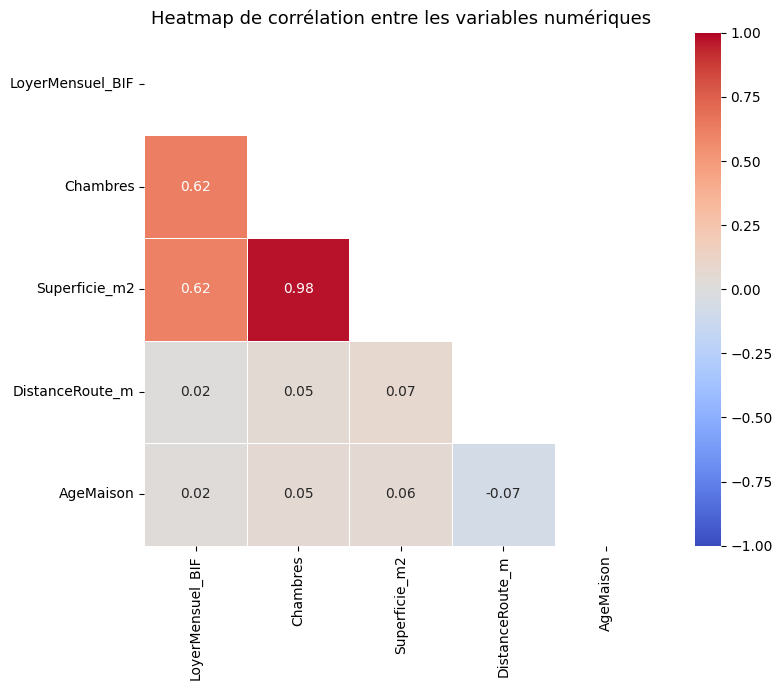

In [17]:
# Liste des variables numériques
num_features = ['LoyerMensuel_BIF', 'Chambres', 'Superficie_m2', 'DistanceRoute_m', 'AgeMaison']

# 1. Calcul de la matrice de corrélation
corr_matrix = recuper_prediction_csv[num_features].corr(method='pearson')

# 2. Affichage de la Heatmap
plt.figure(figsize=(9, 7))

# Utilisation d'un masque pour cacher la partie supérieure symétrique (optionnel mais recommandé)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    square=True,
    linewidths=0.5
)

plt.title("Heatmap de corrélation entre les variables numériques", fontsize=13)
plt.tight_layout()
plt.show()

### Évaluation de la Multicolinéarité avec le VIF (Variance Inflation Factor)

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sélection des features explicatives uniquement (hors variable cible LoyerMensuel_BIF)
X_num = recuper_prediction_csv[['Chambres', 'Superficie_m2', 'DistanceRoute_m', 'AgeMaison']].dropna()

# Calcul du VIF pour chaque feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]

print(" __Variance Inflation Factor (VIF)__ ")
print(vif_data)

 __Variance Inflation Factor (VIF)__ 
           Feature         VIF
0         Chambres  112.333863
1    Superficie_m2  117.808883
2  DistanceRoute_m    3.082685
3        AgeMaison    3.076670


## Visualisation de Features vs LoyerMensuel_BIF

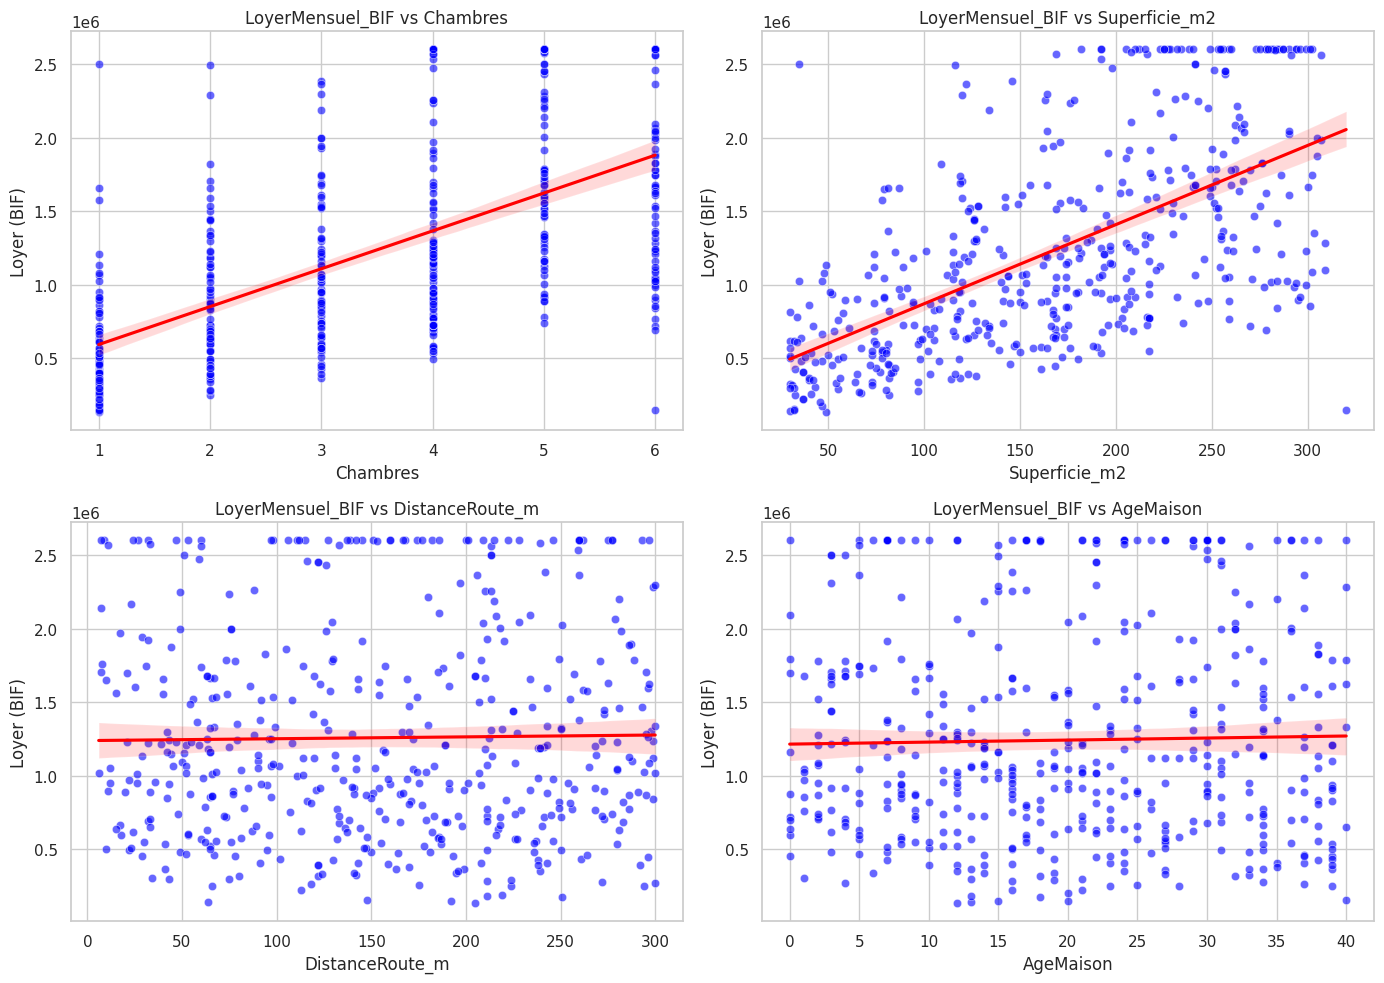

/tmp/ipykernel_2806/118088920.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2806/118088920.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2806/118088920.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2806/118088920.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2806/118088920.py:44: FutureWarning: 

Passin

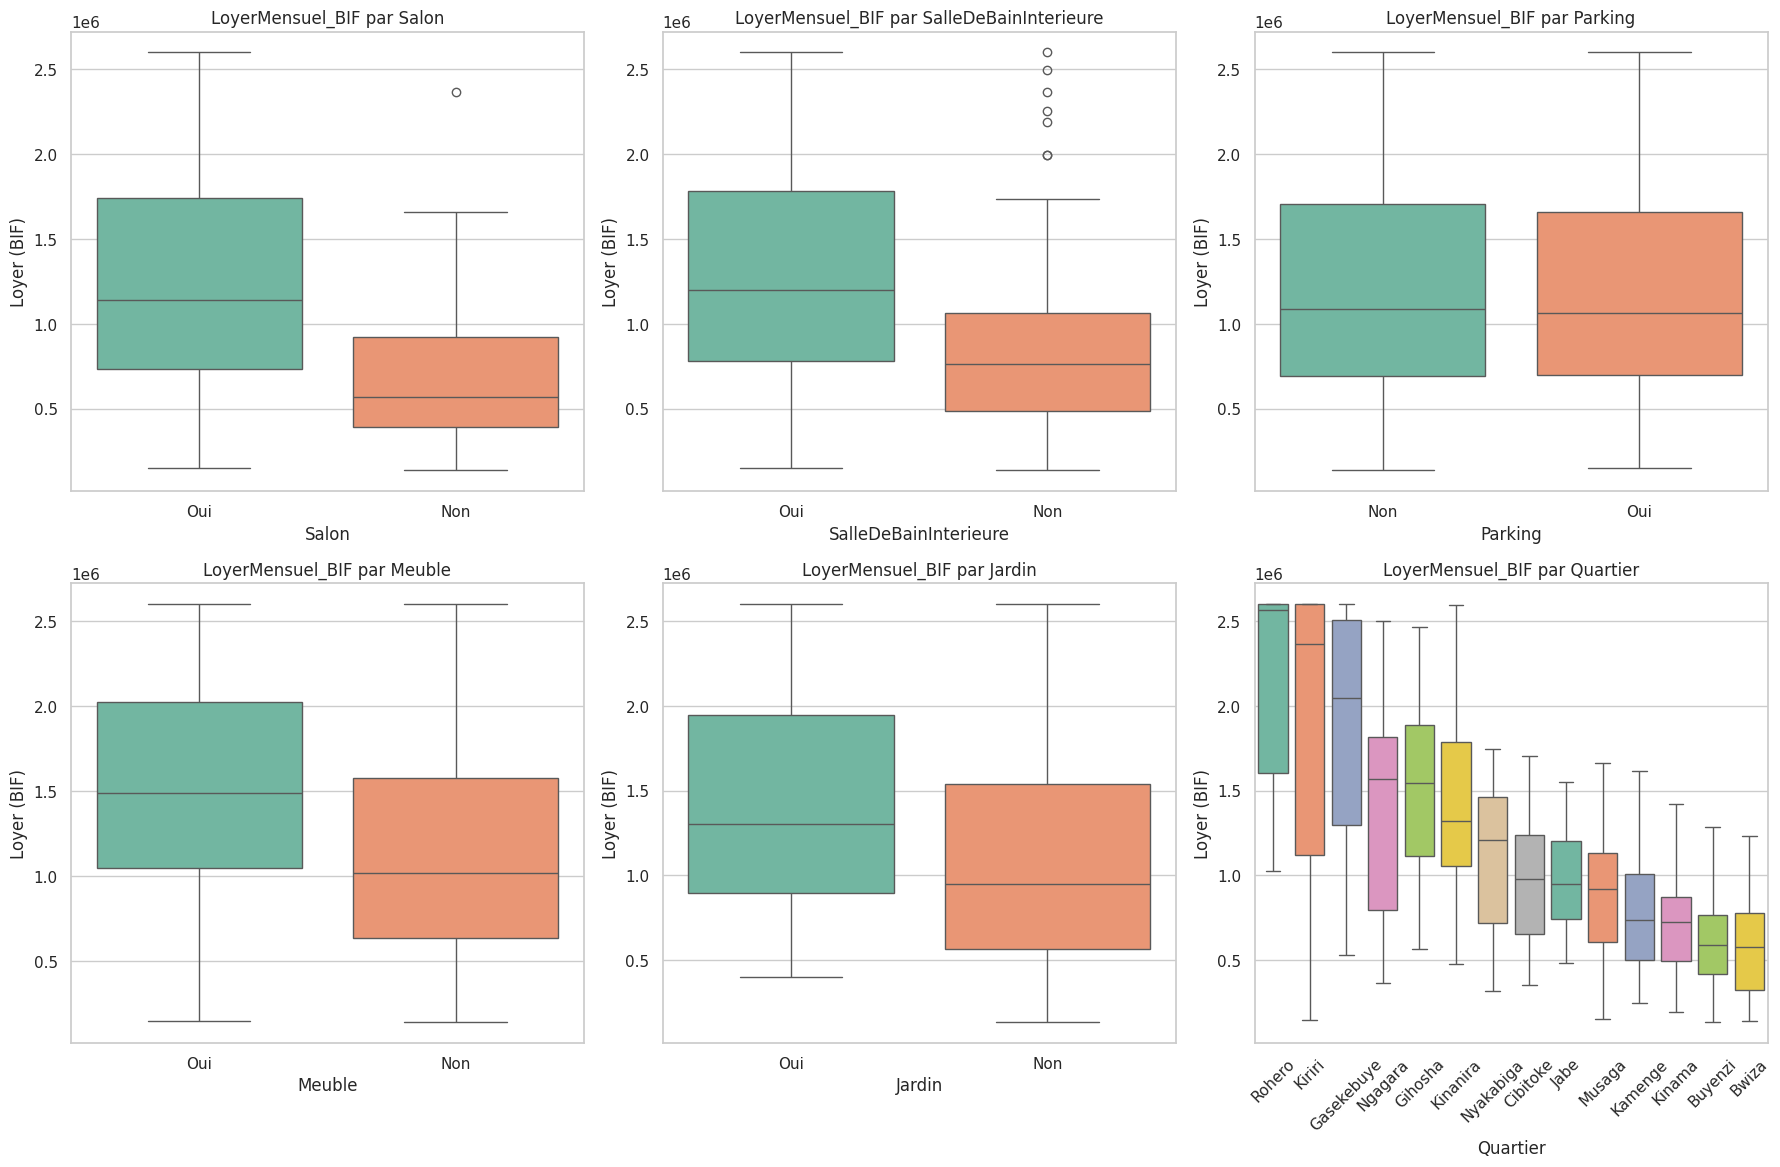

In [19]:
# Configurer le style des graphiques
sns.set_theme(style="whitegrid")

# 1. Variables numériques vs Cible (Scatter plots)
num_features = ['Chambres', 'Superficie_m2', 'DistanceRoute_m', 'AgeMaison']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.scatterplot(
        data=recuper_prediction_csv,
        x=col,
        y='LoyerMensuel_BIF',
        ax=axes[i],
        alpha=0.6,
        color='blue'
    )
    # Ajout d'une ligne de tendance (régression linéaire locale)
    sns.regplot(
        data=recuper_prediction_csv,
        x=col,
        y='LoyerMensuel_BIF',
        ax=axes[i],
        scatter=False,
        color='red'
    )
    axes[i].set_title(f"LoyerMensuel_BIF vs {col}", fontsize=12)
    axes[i].set_ylabel("Loyer (BIF)")

plt.tight_layout()
plt.show()

# 2. Variables catégorielles vs Cible (Boxplots)
cat_features = ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin', 'Quartier']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Tri des catégories par loyer médian pour une meilleure lisibilité
    order = recuper_prediction_csv.groupby(col)['LoyerMensuel_BIF'].median().sort_values(ascending=False).index

    sns.boxplot(
        data=recuper_prediction_csv,
        x=col,
        y='LoyerMensuel_BIF',
        ax=axes[i],
        order=order,
        palette='Set2'
    )
    axes[i].set_title(f"LoyerMensuel_BIF par {col}", fontsize=12)
    axes[i].set_ylabel("Loyer (BIF)")

    if col == 'Quartier':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()